# Qualtran → FTCircuitBench → Azure QRE

**Goal:** take a quantum algorithm from a high-level description all the way to an
estimate of *physical qubits and runtime* on error-corrected hardware — in one
notebook, in a few seconds.

```
 Qualtran                FTCircuitBench                  Azure QRE
 describe the      →     compile to Clifford+T,    →     physical qubits,
 algorithm               count logical resources         runtime, code distance
```

Each tool answers one question:

1. **[Qualtran](https://github.com/quantumlib/Qualtran)** — *what circuit implements
   this algorithm?* It builds fault-tolerant subroutines as composable "Bloqs".
2. **FTCircuitBench** (this package) — *what does that circuit cost logically?* It
   compiles to the fault-tolerant Clifford+T gate set and counts the expensive
   operations (T gates).
3. **[Azure Quantum Resource Estimator](https://learn.microsoft.com/azure/quantum/intro-to-resource-estimation)** —
   *what does that cost physically?* It converts logical counts into physical
   qubits and wall-clock time under a hardware model. It runs locally; no Azure
   account is needed.

FTCircuitBench is the bridge: it accepts the circuit Qualtran produces and emits
the counts Azure QRE consumes.

**Setup** (one time):

```bash
uv sync --extra qualtran --extra qre    # or: uv sync --all-extras
```


## Step 1 — Describe an algorithm in Qualtran

We use a 4-qubit **Quantum Fourier Transform**, a standard subroutine that is small
enough to inspect at every stage.

In [1]:
from qualtran.bloqs.qft import QFTTextBook

bloq = QFTTextBook(4)
bloq

QFTTextBook(bitsize=4, with_reverse=True)

## Step 2 — Hand it to FTCircuitBench

`bloq_to_qiskit` converts the Bloq into a circuit FTCircuitBench can compile.

One flag needs explaining: Qualtran cleans up its ancilla qubits with a
measurement-based trick that costs zero T gates but makes the circuit
non-unitary, and FTCircuitBench analyses unitary circuits.
`unitary_uncompute=True` swaps in the equivalent unitary clean-up (at a small,
exactly-known extra T cost), so the circuit can be analysed. Without the flag,
the conversion raises an error explaining exactly this.

In [2]:
from ftcircuitbench.frontends import bloq_to_qiskit

circuit = bloq_to_qiskit(bloq, unitary_uncompute=True)

print(f"{circuit.num_qubits} qubits, {len(circuit.data)} gates")
print(dict(circuit.count_ops()))

10 qubits, 192 gates
{'cx': 72, 't': 26, 'tdg': 24, 'ry': 24, 'h': 16, 'rx': 12, 's': 9, 'sdg': 6, 'swap': 2, 'rz': 1}


## Step 3 — Compile and count logical resources

`run_pipeline` synthesises the circuit into the **Clifford+T** gate set (the
operations an error-corrected machine can run) and converts it to **Pauli-based
computation** (the form in which such a machine executes it).

The number to watch is the **T count**. On error-corrected hardware, Clifford
gates are cheap but every T gate must be produced by a dedicated "T factory" —
T count is the currency the physical layer charges in.

In [3]:
import pandas as pd

from ftcircuitbench.api import PipelineConfig, run_pipeline

config = PipelineConfig(
    pipeline="gs",              # Gridsynth synthesis
    gridsynth_precision=5,      # ~1e-5 synthesis error per rotation
    optimize_pbc=True,
    calculate_fidelity=False,
)
result = run_pipeline(circuit, config)

logical = result.clifford_stats
pd.Series(
    {
        "logical qubits": logical["num_qubits"],
        "total gates": logical["total_gate_count"],
        "T count": logical["total_t_family_count"],
        "circuit depth": logical["depth"],
        "PBC rotation operators": result.pbc_stats["pbc_rotation_operators"],
    },
    name="QFT(4), compiled",
    dtype=object,
).to_frame()

,"QFT(4), compiled"
logical qubits,10
total gates,514
T count,124
circuit depth,365
PBC rotation operators,96


## Step 4 — Estimate physical resources with Azure QRE

The logical counts — qubits, T count, measurements — are all the estimator needs.
We ask for two superconducting hardware models that differ only in their physical
error rate ($10^{-3}$ vs $10^{-4}$).

In [4]:
from ftcircuitbench.resource_estimation import (
    LogicalResourceCounts,
    estimate_circuit,
    resolve_hardware_models,
)

models = resolve_hardware_models(["superconducting 1e-3", "superconducting 1e-4"])

counts = LogicalResourceCounts(
    label="qft-4",
    num_qubits=logical["num_qubits"],
    t_count=logical["total_t_family_count"],
    measurement_count=logical["num_qubits"],
)
estimate = estimate_circuit(counts, models=models)

pd.DataFrame(
    {
        name: {
            "physical qubits": f"{e.physical_qubits:,}",
            "runtime (ms)": round(e.runtime_seconds * 1e3, 3),
            "code distance": e.code_distance,
            "T factories": e.num_t_factories,
        }
        for name, e in estimate.estimates.items()
    }
)

,superconducting 1e-3,superconducting 1e-4
physical qubits,"44,060","4,380"
runtime (ms),0.482,0.268
code distance,9,5
T factories,10,8


That is the whole pipeline: **10 logical qubits became tens of thousands of
physical ones**, most of them spent making T states rather than running the
algorithm — and better physical qubits (the $10^{-4}$ column) cut the bill by
an order of magnitude. These are the numbers that decide what hardware an
algorithm actually needs, and none of them are visible from the algorithm
description alone.

## The same pipeline, swept over problem size

Because each step is one function call, scanning a family of circuits is a short
loop. Here is the QFT from 3 to 8 qubits.

In [5]:
records = []
for n in range(3, 9):
    qc = bloq_to_qiskit(QFTTextBook(n), unitary_uncompute=True)
    stats = run_pipeline(qc, config).clifford_stats
    est = estimate_circuit(
        LogicalResourceCounts(
            label=f"qft-{n}",
            num_qubits=stats["num_qubits"],
            t_count=stats["total_t_family_count"],
            measurement_count=stats["num_qubits"],
        ),
        models=models,
    )
    records.append(
        {
            "QFT width": n,
            "logical qubits": stats["num_qubits"],
            "T count": stats["total_t_family_count"],
            **{
                f"physical qubits ({name})": e.physical_qubits
                for name, e in est.estimates.items()
            },
            **{
                f"runtime ms ({name})": round(e.runtime_seconds * 1e3, 2)
                for name, e in est.estimates.items()
            },
        }
    )

sweep = pd.DataFrame(records).set_index("QFT width")
sweep

,logical qubits,T count,physical qubits (superconducting 1e-3),physical qubits (superconducting 1e-4),runtime ms (superconducting 1e-3),runtime ms (superconducting 1e-4)
QFT width,,,,,,
3,6,37,52920,378,0.12,0.05
4,10,124,44060,4380,0.48,0.27
5,15,273,91044,15100,1.04,0.58
6,21,484,84832,15800,2.22,1.01
7,28,759,88704,16600,3.46,1.57
8,36,1092,93060,17500,4.96,2.26


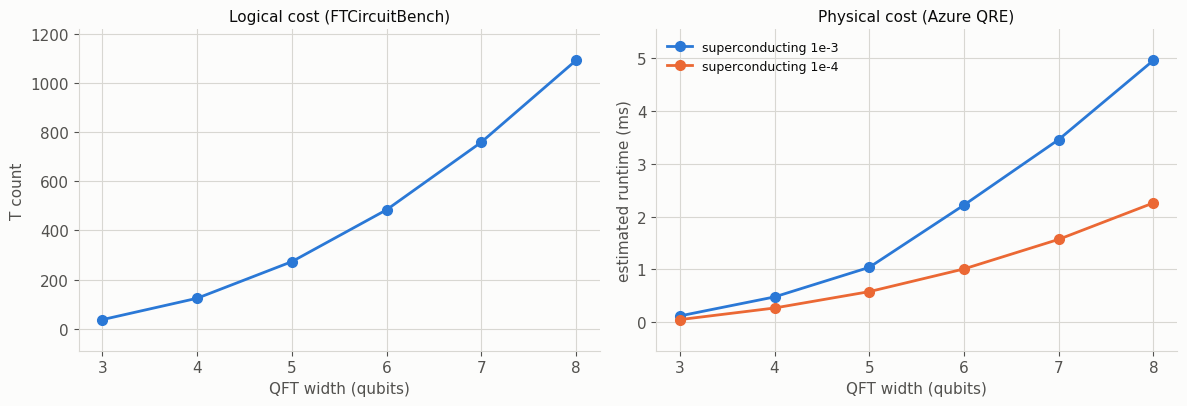

In [6]:
import matplotlib.pyplot as plt

BLUE, ORANGE = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#d8d7d2", "axes.labelcolor": "#52514e",
    "text.color": "#0b0b0b", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 11, "axes.grid": True, "grid.color": "#d8d7d2",
    "axes.spines.top": False, "axes.spines.right": False,
})

fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.2))

left.plot(sweep.index, sweep["T count"], marker="o", markersize=7,
          linewidth=2, color=BLUE)
left.set_xlabel("QFT width (qubits)")
left.set_ylabel("T count")
left.set_title("Logical cost (FTCircuitBench)", fontsize=11)
left.margins(y=0.12)

for colour, model in zip([BLUE, ORANGE], models):
    right.plot(sweep.index, sweep[f"runtime ms ({model.name})"], marker="o",
               markersize=7, linewidth=2, color=colour, label=model.name)
right.set_xlabel("QFT width (qubits)")
right.set_ylabel("estimated runtime (ms)")
right.set_title("Physical cost (Azure QRE)", fontsize=11)
right.margins(y=0.12)
right.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

## Where to go from here

- **Any Qualtran Bloq works the same way** — arithmetic, data loading, chemistry
  primitives: `bloq_to_qiskit(bloq, unitary_uncompute=True)` and the rest is
  identical.
- **CLI equivalents** — `import_circuit.py` (convert), `analyze_circuit.py`
  (compile), `estimate_resources.py` (estimate). See
  [`docs/examples.md`](../docs/examples.md).
- **pyLIQTR** circuits enter the same pipeline as OpenQASM files exported with
  `tools/export_cirq_qasm.py` (pyLIQTR's pinned dependencies require their own
  environment; see [`docs/installation.md`](../docs/installation.md)).
- **FTCircuitBench in depth** — [`FTCircuitBench_Pipeline_Demo.ipynb`](FTCircuitBench_Pipeline_Demo.ipynb) covers the
  compilation pipeline, PBC analysis, and visualisation.
